<a href="https://colab.research.google.com/github/Revathisulochana/Python---Social-Media-Engagement-Analytics/blob/main/Python_For_Data_Analysis_Project_Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Python For Data Analysis Project-Social Media Engagement Analytics ##



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [ ]:
# Data Import & Setup
from google.colab import files
uploaded = files.upload()
file_path = "social_media_engagement_5000.csv"
df = pd.read_csv(file_path)
df.head()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Convert date columns to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)


In [ ]:
# Check missing values
print(df.isnull().sum())


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
# Duplicate Handling- Identify & remove duplicates

duplicates = df.duplicated().sum()
print("Duplicate rows: ", duplicates)

Duplicate rows:  0


In [ ]:
# Data Formatting
# Fix incorrect data types # Standardize categories (e.g., gender labels)

df['gender'].value_counts()

,count
gender,
Male,1849
Other,1581
Female,1570


In [ ]:
# Correct unrealistic values in likes, comments, shares
df[['likes', 'comments', 'shares']].agg(['min', 'max'])

,likes,comments,shares
min,10.0,0.0,0.0
max,19998.0,2999.0,1999.0


In [ ]:
# Feature Cleaning
# Extract hashtag count
df['hashtag_count'] = df['hashtags'].fillna('').apply(
    lambda x: len(x.split()) if x != '' else 0
)
df[['hashtags', 'hashtag_count']].head()


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [ ]:
# Clean sentiment labels
df['sentiment'].value_counts()

,count
sentiment,
positive,2513
neutral,1527
negative,960


In [ ]:
#  Data Exploration using Pandas
#  View dataset structure using head(), tail(), shape, and columns.
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape


(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
# Check data types and info with info() and dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
# Generate summary statistics using describe().
display(df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,5000.0,NaN,NaN,NaN,54561.8908,10055.0,32309.5,54374.5,77180.5,99963.0,26090.370121
age,5000.0,NaN,NaN,NaN,38.4404,13.0,26.0,38.0,51.0,64.0,14.687151
gender,5000,3,Male,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,India,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,5000.0,NaN,NaN,NaN,548042.909,100068.0,322543.5,548077.5,771574.5,999455.0,260646.957267
post_type,5000,4,reel,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_category,5000,8,fitness,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,5000.0,NaN,NaN,NaN,10106.9974,10.0,5235.0,10105.5,14959.0,19998.0,5702.293017
comments,5000.0,NaN,NaN,NaN,1502.0398,0.0,792.0,1497.0,2235.25,2999.0,856.393312
shares,5000.0,NaN,NaN,NaN,1002.9106,0.0,511.0,1012.0,1483.0,1999.0,570.8552


In [ ]:
#  Analyze categorical distributions using value_counts(), unique(), and nunique().
df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [ ]:
df['post_type'].nunique()

4

In [ ]:
# Create a correlation matrix for numeric fields.
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [ ]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).
avg_likes_post_type = df.groupby("post_type")["likes"].mean().sort_values(ascending=False)
avg_impressions_country = df.groupby("country")["impression_count"].mean().sort_values(ascending=False)
display(avg_likes_post_type)
display(avg_impressions_country)


,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


,impression_count
country,
India,52462.386916
France,51727.673387
USA,51263.872255
UK,51119.393509
Japan,49616.135593
Brazil,49193.174603
UAE,48928.413519
Canada,48703.150097
Germany,48605.406122


In [ ]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [ ]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df[['likes', 'comments', 'shares', 'engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score'],
      dtype='object')

In [ ]:
df.groupby('post_type')['engagement_score'].mean()

,engagement_score
post_type,
image,12649.390537
reel,12524.031567
text,12613.243775
video,12664.594286


In [ ]:
df.groupby('country')['engagement_rate'].mean()

,engagement_rate
country,
Australia,1.324339
Brazil,1.540704
Canada,0.916659
France,1.146402
Germany,0.759000
India,0.655005
Japan,0.769623
UAE,1.112352
UK,0.850966


In [ ]:
df.groupby('sentiment')['engagement_score'].mean()

,engagement_score
sentiment,
negative,12731.498958
neutral,12448.163720
positive,12665.799443


In [ ]:
df_part1 = df.iloc[:2500]
df_part2 = df.iloc[2500:]

print(df_part1.shape)
print(df_part2.shape)

(2500, 21)
(2500, 21)


In [ ]:
combined_df = pd.concat([df_part1, df_part2])
combined_df.shape

(5000, 21)

In [ ]:
#  Statistical Analysis
# Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:
stats_columns = ['likes', 'comments', 'shares', 'watch_time_sec',
                 'engagement_rate', 'follower_count']
stats_df = df[stats_columns]
stats_df.head()



,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,7011.0,354.0,1157.0,5726,0.190862,81734
1,11750.0,2606.0,1807.0,5947,0.201493,5963
2,4862.0,344.0,955.0,6946,0.137345,501783
3,5350.0,1083.0,1049.0,229,0.106195,480212
4,12682.0,2735.0,1300.0,4798,2.777372,383936


In [ ]:
# ● Mean, median, mode
stats_df.mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
stats_df.median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
stats_df.mode().head(1)

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10105.5,1497.0,1012.0,916.0,0.006363,497502.0


In [61]:
stats_df.std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [62]:
stats_df.var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [63]:
stats_df.quantile([0.25, 0.50, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [64]:
stats_df.skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [65]:
stats_df.kurt()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [12]:
from google.colab import files
uploaded = files.upload()
file_path = "social_media_engagement_5000.csv"
df = pd.read_csv(file_path)
df.head()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


Data Visualization

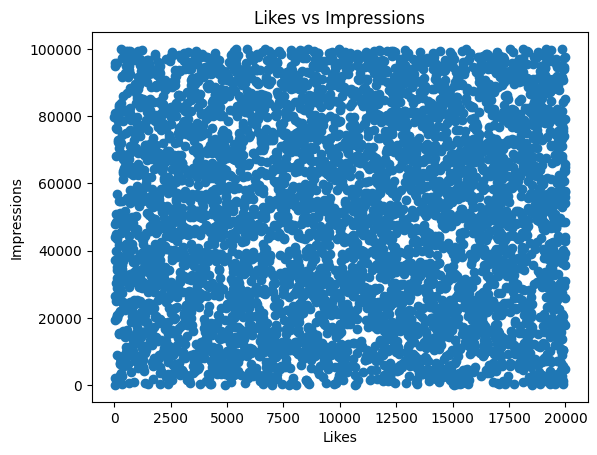

In [13]:
# Matplotlib:
# Scatter plot: Likes vs Impressions
plt.scatter(df['likes'], df['impression_count'])
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.title('Likes vs Impressions')
plt.show()

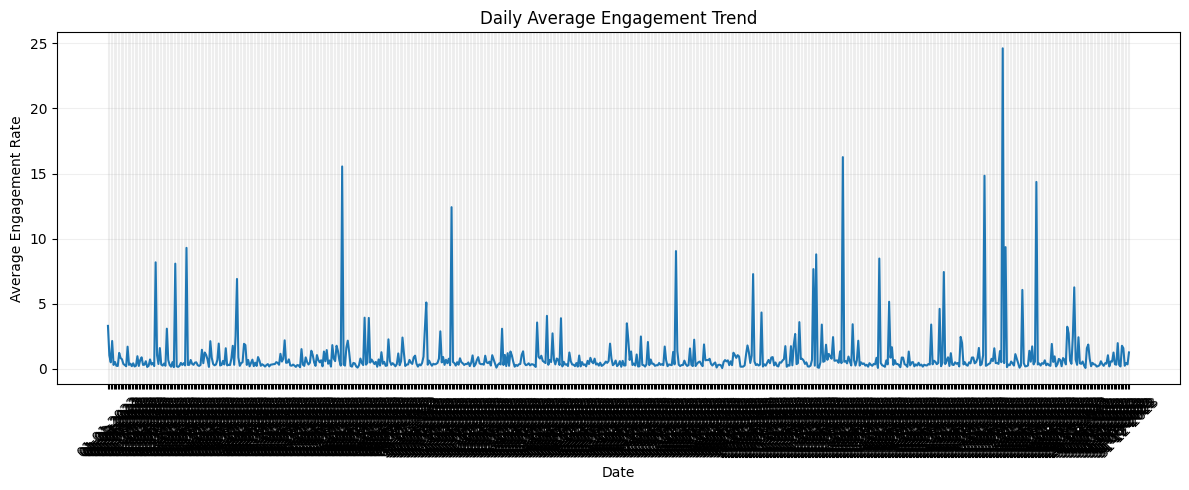

In [14]:
#Line: Daily engagement trend
daily_engagement = df.groupby("posted_at")["engagement_rate"].mean().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.title("Daily Average Engagement Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

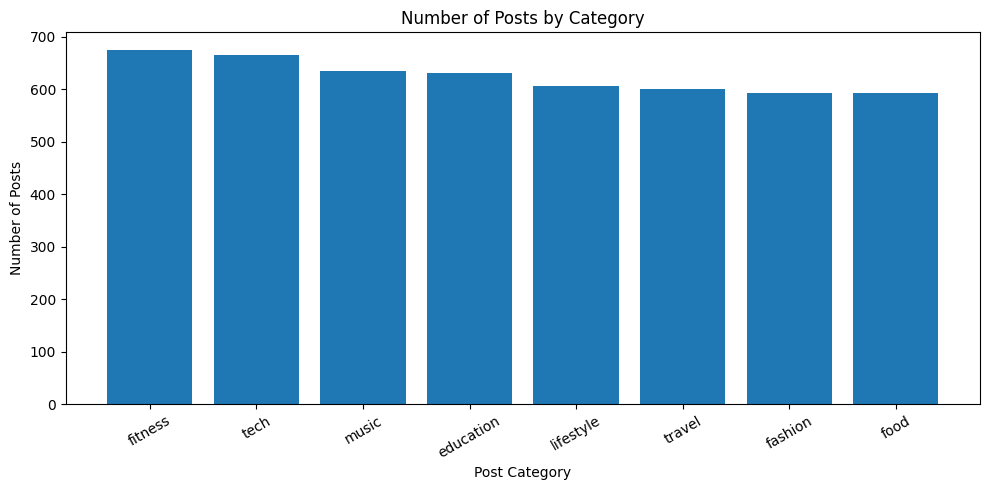

In [15]:
# Bar: Posts by category
category_counts = df["post_category"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

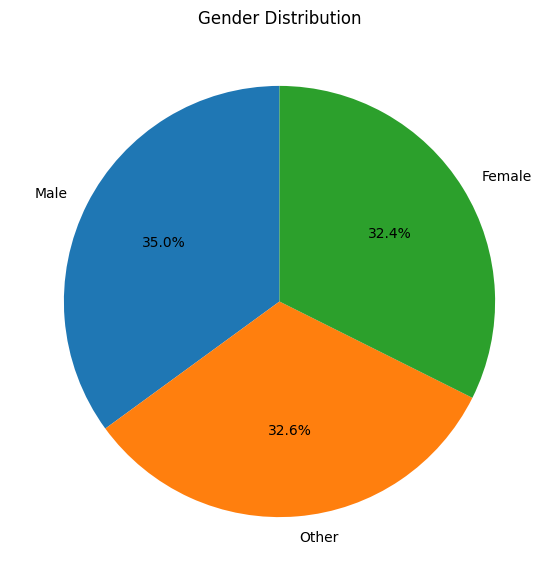

In [16]:
# Pie: Gender distribution
gender_counts = df["gender"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.show()

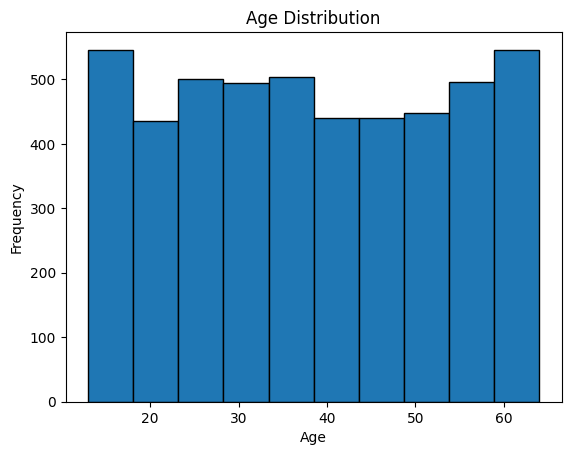

In [17]:
# Histogram: age
plt.hist(df['age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

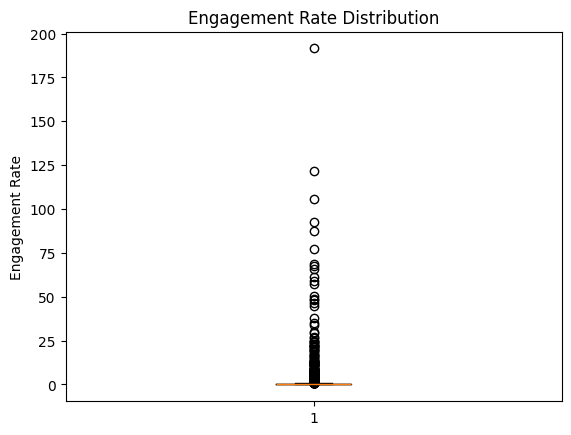

In [18]:
# Box: engagement rate
plt.boxplot(df['engagement_rate'])
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

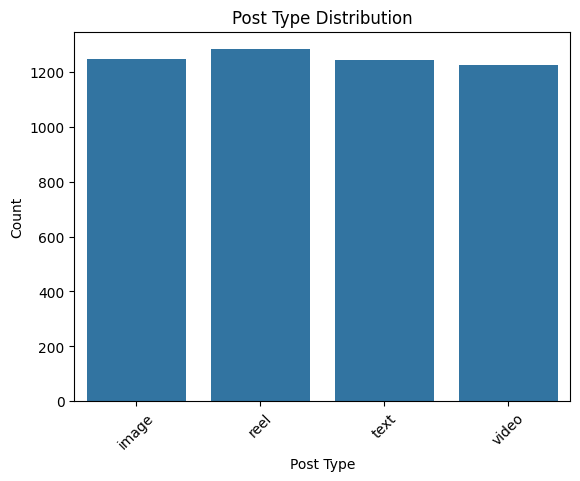

In [19]:
## Seaborn
# Count plot: post type
sns.countplot(x='post_type', data=df)
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.title('Post Type Distribution')
plt.xticks(rotation=45)
plt.show()

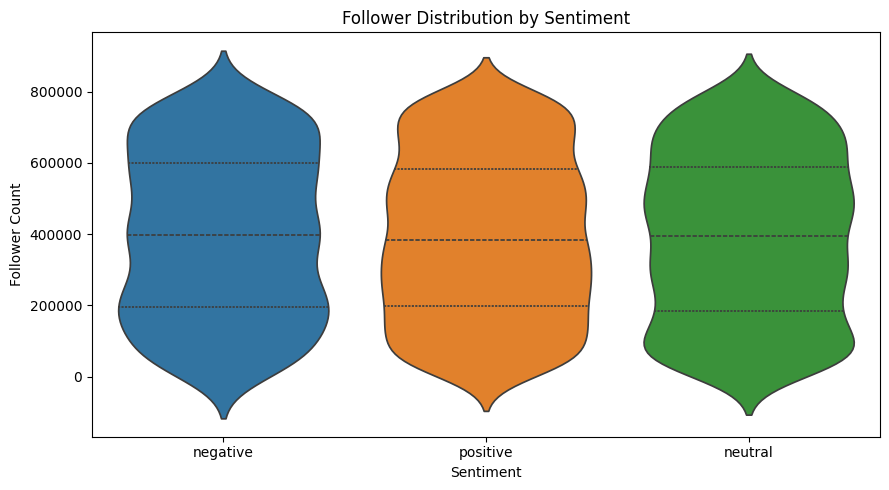

In [20]:
# Violin plot: Followers vs sentiment
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="sentiment", y="follower_count", hue="sentiment", inner="quartile", legend=False)
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.title("Follower Distribution by Sentiment")
plt.tight_layout()
plt.show()

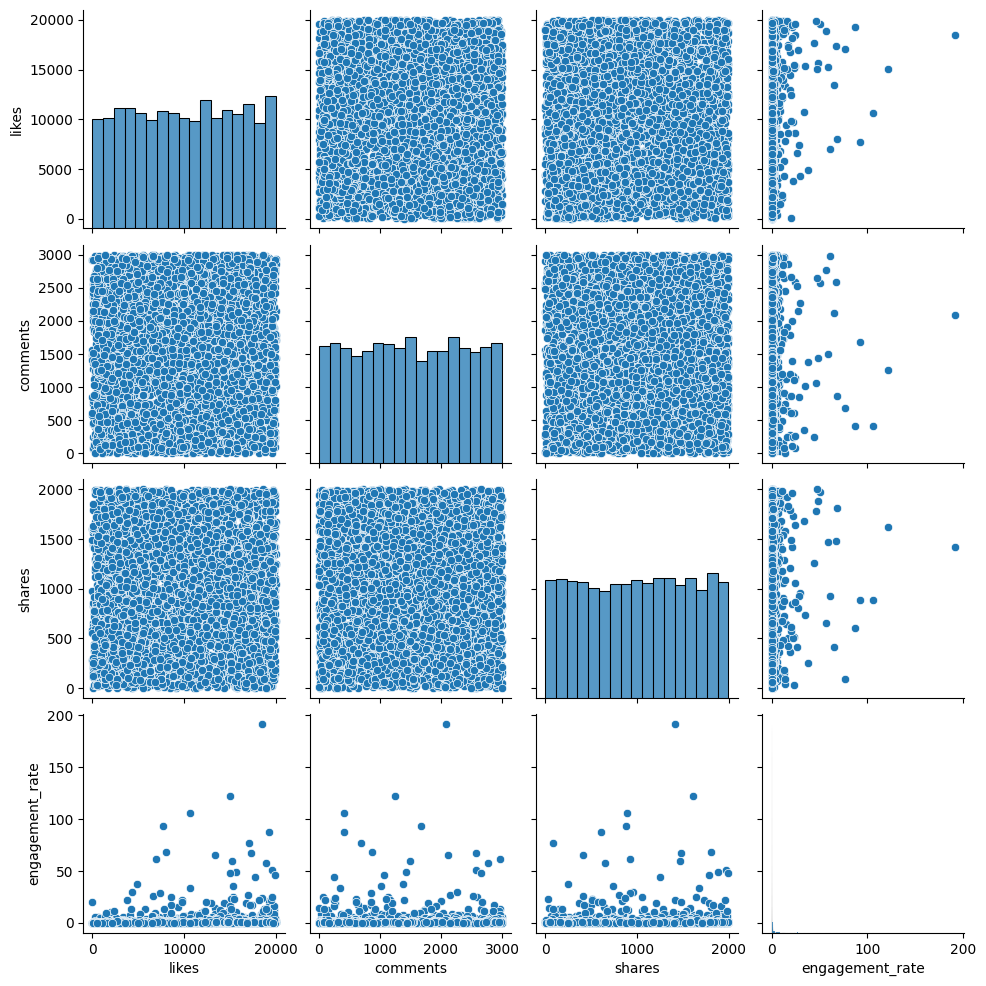

In [23]:
# Pair plot: numeric features
pair_data = df[['likes', 'comments', 'shares', 'engagement_rate']]
sns.pairplot(pair_data)
plt.show()

In [24]:
import plotly.express as px

In [25]:
# Plotly (Interactive)
# Interactive line chart/bar chart/bubble/scatter chart
fig = px.scatter(
    df,
    x='impression_count',
    y='likes',
    color='post_type',
    title='Interactive Likes vs Impressions'
)

fig.show()

# Insights #

In [28]:
# Insights:
df.groupby("post_type")["engagement_rate"].mean().sort_values(ascending=False)


,engagement_rate
post_type,
video,1.122365
text,1.064549
image,0.895646
reel,0.783047


In [29]:
df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [30]:
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [31]:
df.groupby("age")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
age,
24.0,2.897327
55.0,2.599106
51.0,2.397295
48.0,1.675878
50.0,1.552627
41.0,1.540070
35.0,1.521596
47.0,1.402015
42.0,1.350772


In [32]:
df.groupby("is_verified")["engagement_rate"].mean()

,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [36]:
df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)

,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


In [37]:
df.groupby("sentiment")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.954800


In [39]:
print("Best Post Type:")
print(df.groupby("post_type")["engagement_rate"].mean().idxmax())
print("\nBest Content Category:")
print(df.groupby("post_category")["engagement_rate"].mean().idxmax())

print("\nBest Country:")
print(df.groupby("country")["engagement_rate"].mean().idxmax())

print("\nVerified Account Performance:")
print(df.groupby("is_verified")["engagement_rate"].mean())

Best Post Type:
video

Best Content Category:
food

Best Country:
Brazil

Verified Account Performance:
is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64
